In [253]:
import pandas as pd
import datetime

In [254]:
data = pd.read_csv('LECLERC_cleaned.csv')

In [255]:
def calculate_days(row):
    date_range = row['Delivery Date']
    date_range = date_range.replace('Prévue entre le ', '')
    date_range = date_range.replace('Prévue le ', '')
    if ' et le ' in date_range:
        max_date = date_range.split(' et le ')[-1]
    else:
        max_date = date_range
    max_date_dt = datetime.datetime.strptime(max_date, '%d/%m/%y')
    scrap_date = datetime.datetime.strptime(row['Timestamp'], '%d/%m/%Y %H:%M:%S')
    scrap_date = datetime.datetime.combine(scrap_date.date(), datetime.time(0, 0))
    
    difference = (max_date_dt - scrap_date).days
    
    return difference

In [256]:
import numpy as np

def calculate_experience(row):
    if not pd.isna(row['SellerActivityDate']):
        start = str(row['SellerActivityDate'])
        start_dt = datetime.datetime.strptime(start, '%d/%m/%Y')
        try:
            scrap_date = datetime.datetime.strptime(row['Timestamp'], '%d/%m/%Y %H:%M:%S')
        except ValueError as e:
            print(f"Error parsing timestamp: {row['Timestamp']}")
            raise e
        
        scrap_date = scrap_date.date()
        start_dt = start_dt.date()
        
        difference = (scrap_date - start_dt).days
    else:
        difference = np.nan
    
    return difference 



In [257]:
data['shipping_days'] = data.apply(calculate_days, axis=1)

Ajout des infos vendeurs 

In [258]:
data.drop(columns = ['Seller Rating','Delivery Date','Platform'],inplace=True)

In [259]:
seller = pd.read_csv('Sellers.csv')
seller.drop(columns = ['SellerStatus'],inplace=True)

In [260]:
data_merge = pd.merge(data,seller,how='left',on='Seller')

In [261]:
data_merge.head()

,Product Name,Seller,Price,Delivery Fees,Product State,Timestamp,ID,shipping_days,Seller Rating,NbSellerRatings,SellerActivityDate,SellerCountry
0,"Apple iPhone 16 15,5 cm (6.1"") Double SIM iOS ...",E.Leclerc,1349.00,Offerte,NEUF,24/12/2024 13:30:11,160f282c-11af-427d-8ea5-a98d1badba9c,4,NaN,NaN,NaN,France
1,"Apple iPhone 16 15,5 cm (6.1"") Double SIM iOS ...",Icoza,1408.17,Offerte,NEUF,24/12/2024 13:30:11,98b12821-acb5-4aa6-a5d4-129db155e1d9,4,4.0,140.0,11/09/2020,France
2,"Apple iPhone 16 15,5 cm (6.1"") Double SIM iOS ...",Stock e-commerce,1409.17,Offerte,NEUF,24/12/2024 13:30:11,5ace8dfe-bef8-428f-9a20-eda099c4661a,4,4.0,242.0,17/06/2021,France
3,"Apple iPhone 16 15,5 cm (6.1"") Double SIM iOS ...",Maxmovil,1432.28,Offerte,NEUF,24/12/2024 13:30:11,5e16f708-0b47-4d88-9e49-ef4d3dd29796,4,4.0,14.0,25/06/2021,Espagne
4,"Apple iPhone 16 15,5 cm (6.1"") Double SIM iOS ...",Monsieurplus,1473.99,Offerte,NEUF,24/12/2024 13:30:11,d282bc92-68ff-4039-9239-32e2443a6a19,4,4.0,7.0,20/12/2022,France


In [262]:
data_merge.isna().sum()/len(data_merge)

Product Name          0.000000
Seller                0.000000
Price                 0.000000
Delivery Fees         0.000000
Product State         0.000000
Timestamp             0.000000
ID                    0.000000
shipping_days         0.000000
Seller Rating         0.109126
NbSellerRatings       0.109126
SellerActivityDate    0.109126
SellerCountry         0.000000
dtype: float64

In [263]:
data_merge[data_merge['SellerActivityDate'].apply(lambda x: isinstance(x, float))].head(3)

,Product Name,Seller,Price,Delivery Fees,Product State,Timestamp,ID,shipping_days,Seller Rating,NbSellerRatings,SellerActivityDate,SellerCountry
0,"Apple iPhone 16 15,5 cm (6.1"") Double SIM iOS ...",E.Leclerc,1349.0,Offerte,NEUF,24/12/2024 13:30:11,160f282c-11af-427d-8ea5-a98d1badba9c,4,NaN,NaN,NaN,France
9,"Apple iPhone 16 15,5 cm (6.1"") Double SIM iOS ...",E.Leclerc,1098.0,Offerte,NEUF,24/12/2024 13:30:17,3daccedd-2936-4a16-bb57-abf5e372681c,4,NaN,NaN,NaN,France
19,Non trouvé,E.Leclerc,969.0,Offerte,Non trouvé,24/12/2024 13:30:24,b22e1674-9148-4c9c-8afa-071b9cf27bbf,4,NaN,NaN,NaN,France


In [264]:
data_merge['SellerExperience'] = data_merge.apply(calculate_experience, axis=1)

In [265]:
data_merge.isna().sum()

Product Name              0
Seller                    0
Price                     0
Delivery Fees             0
Product State             0
Timestamp                 0
ID                        0
shipping_days             0
Seller Rating         22406
NbSellerRatings       22406
SellerActivityDate    22406
SellerCountry             0
SellerExperience      22406
dtype: int64

Suppression de delivery fees car sont tous = offerte

In [266]:
columns_to_delete = ['Delivery Fees','SellerActivityDate','Seller','Product State']

In [267]:
#Supprimer la catégorie d'état de téléphone la plus fréquente comme variable de reférence
len(data_merge[data_merge['Product State'] == 'NEUF']['ID'].unique())/len(data_merge['ID'].unique())

0.910958904109589

In [268]:
dummies_state = pd.get_dummies(data_merge['Product State'], drop_first=True)
data_merge = pd.concat([data_merge, dummies_state], axis=1)

In [274]:
data_merge['SellerCountry'].unique()

array(['France', 'Espagne', 'Luxembourg', 'Lettonie', 'Italie'],
      dtype=object)

In [272]:
data_merge['SellerCountry'].replace({
    'France       ':'France'
},inplace=True)

In [276]:
dummies_country = pd.get_dummies(data_merge['SellerCountry'])
dummies_country.drop('France', axis=1, inplace=True)
data_merge = pd.concat([data_merge, dummies_country], axis=1)

In [277]:
data_merge.head()

,Product Name,Seller,Price,Delivery Fees,Product State,Timestamp,ID,shipping_days,Seller Rating,NbSellerRatings,...,Non trouvé,OCCASION - BON ÉTAT,OCCASION - EXCELLENT ÉTAT,OCCASION - PARFAIT - JAMAIS UTILISÉ,OCCASION - TRÉS BON ÉTAT,OCCASION - ÉTAT CORRECT,Espagne,Italie,Lettonie,Luxembourg
0,"Apple iPhone 16 15,5 cm (6.1"") Double SIM iOS ...",E.Leclerc,1349.00,Offerte,NEUF,24/12/2024 13:30:11,160f282c-11af-427d-8ea5-a98d1badba9c,4,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
1,"Apple iPhone 16 15,5 cm (6.1"") Double SIM iOS ...",Icoza,1408.17,Offerte,NEUF,24/12/2024 13:30:11,98b12821-acb5-4aa6-a5d4-129db155e1d9,4,4.0,140.0,...,False,False,False,False,False,False,False,False,False,False
2,"Apple iPhone 16 15,5 cm (6.1"") Double SIM iOS ...",Stock e-commerce,1409.17,Offerte,NEUF,24/12/2024 13:30:11,5ace8dfe-bef8-428f-9a20-eda099c4661a,4,4.0,242.0,...,False,False,False,False,False,False,False,False,False,False
3,"Apple iPhone 16 15,5 cm (6.1"") Double SIM iOS ...",Maxmovil,1432.28,Offerte,NEUF,24/12/2024 13:30:11,5e16f708-0b47-4d88-9e49-ef4d3dd29796,4,4.0,14.0,...,False,False,False,False,False,False,True,False,False,False
4,"Apple iPhone 16 15,5 cm (6.1"") Double SIM iOS ...",Monsieurplus,1473.99,Offerte,NEUF,24/12/2024 13:30:11,d282bc92-68ff-4039-9239-32e2443a6a19,4,4.0,7.0,...,False,False,False,False,False,False,False,False,False,False


In [278]:
data_merge.drop(columns = columns_to_delete,inplace=True)

In [279]:
data_merge.isna().sum()

Product Name                               0
Price                                      0
Timestamp                                  0
ID                                         0
shipping_days                              0
Seller Rating                          22406
NbSellerRatings                        22406
SellerCountry                              0
SellerExperience                       22406
Non trouvé                                 0
OCCASION - BON ÉTAT                        0
OCCASION - EXCELLENT ÉTAT                  0
OCCASION - PARFAIT - JAMAIS UTILISÉ        0
OCCASION - TRÉS BON ÉTAT                   0
OCCASION - ÉTAT CORRECT                    0
Espagne                                    0
Italie                                     0
Lettonie                                   0
Luxembourg                                 0
dtype: int64

Fillna des téléphones vendus par Leclerc par la moyenne des autres 

In [292]:
mean_nb_rating = data_merge['NbSellerRatings'].mean()
mean_nb_rating

np.float64(79.60978476576808)

In [293]:
median_rating = data_merge['Seller Rating'].median()
data_merge['Seller Rating'].fillna(median_rating, inplace=True)
data_merge['NbSellerRatings'].fillna(mean_nb_rating, inplace=True)

C:\Users\zoero\AppData\Local\Temp\ipykernel_12236\2506381378.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_merge['Seller Rating'].fillna(median_rating, inplace=True)
C:\Users\zoero\AppData\Local\Temp\ipykernel_12236\2506381378.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a

In [306]:
median_seller_experience = data_merge['SellerExperience'].median()
data_merge['SellerExperience'].fillna(median_seller_experience,inplace=True)

C:\Users\zoero\AppData\Local\Temp\ipykernel_12236\1889923872.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_merge['SellerExperience'].fillna(median_seller_experience,inplace=True)


In [309]:
data_merge.drop(columns=['SellerCountry'],inplace=True)

In [310]:
data_merge.isna().sum()

Product Name                           0
Price                                  0
Timestamp                              0
ID                                     0
shipping_days                          0
Seller Rating                          0
NbSellerRatings                        0
SellerExperience                       0
Non trouvé                             0
OCCASION - BON ÉTAT                    0
OCCASION - EXCELLENT ÉTAT              0
OCCASION - PARFAIT - JAMAIS UTILISÉ    0
OCCASION - TRÉS BON ÉTAT               0
OCCASION - ÉTAT CORRECT                0
Espagne                                0
Italie                                 0
Lettonie                               0
Luxembourg                             0
dtype: int64

In [ ]:
data_merge.

AttributeError: 'DataFrame' object has no attribute 'summary'

TypeError: Image data of dtype object cannot be converted to float

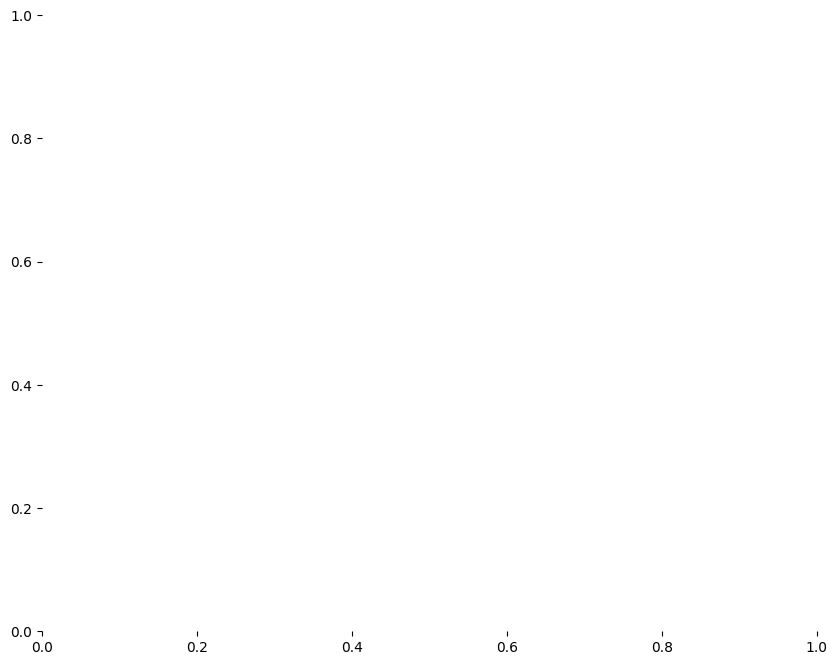

In [311]:
import seaborn as sns
import matplotlib.pyplot as plt

# Créer le heatmap
plt.figure(figsize=(10, 8))  # Taille de la figure
sns.heatmap(data_merge.drop(columns=['Product Name','Timestamp','ID']), annot=True, cmap='coolwarm')  # 'annot=True' pour afficher les valeurs dans les cases
plt.title('Heatmap Example')  # Ajouter un titre
plt.show()  # Afficher le graphique
